# Analyze Baselines

In [24]:
from pathlib import Path
import os
import json
from itertools import product

import pandas as pd

In [25]:
from temp import (
    mis_metrics,
    plot_mis_predictions
)

## Load Original Flows

In [26]:
# Configuration
dataset = "aitv2"
scenario = "fox"

out_dir = Path(f"../reports/baselines/{dataset}/{scenario}/temp")
out_dir.mkdir(parents=True, exist_ok=True)

In [27]:
df = pd.read_csv(
    f"../data/interim/{dataset}/{scenario}/flows_labeled/all_flows_labeled.csv"
)

df = df.sort_values("start_time").reset_index(drop=True)
df['t_rel'] = df['start_time'] - df['start_time'].min()

In [28]:
phase_bounds = (
    df[df['phase'] > 0]
    .groupby('phase')['t_rel']
    .agg(['min', 'max'])
)

phase_start = phase_bounds['min'].to_dict()
phase_end   = phase_bounds['max'].to_dict()

In [29]:
phase_bounds

,min,max
phase,,
1,302353.638809,304668.057688
2,304679.807969,304706.937194
3,304708.681596,306808.561706
4,306831.955887,306831.963536


## Temp Plots and Custom Metrics

In [30]:
models = [
    "multiclass",
    "ensemble",
]

file_paths = []

for model in models:
    folder = Path(f"../experiments/{dataset}/{scenario}/baselines/{model}/metrics/")
    file_paths.extend(list(folder.iterdir()))

print(len(file_paths))

6


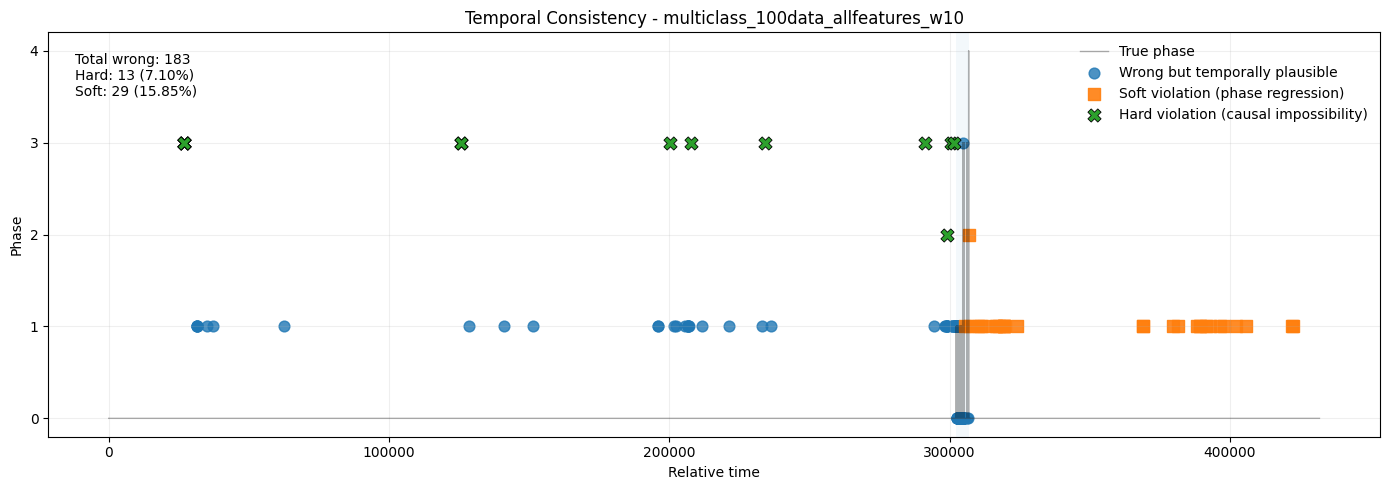

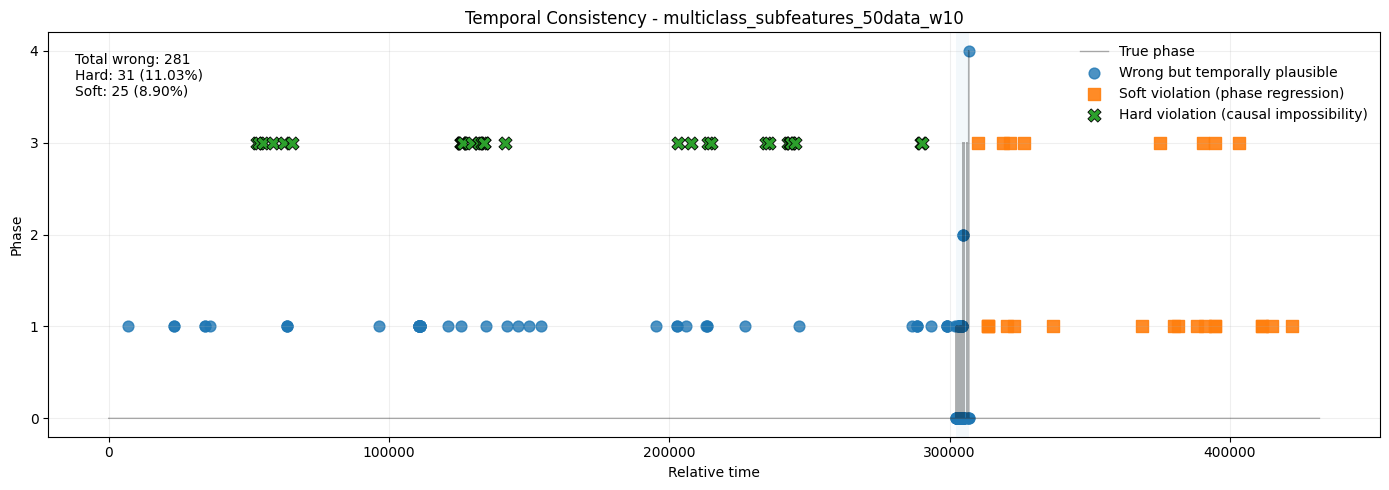

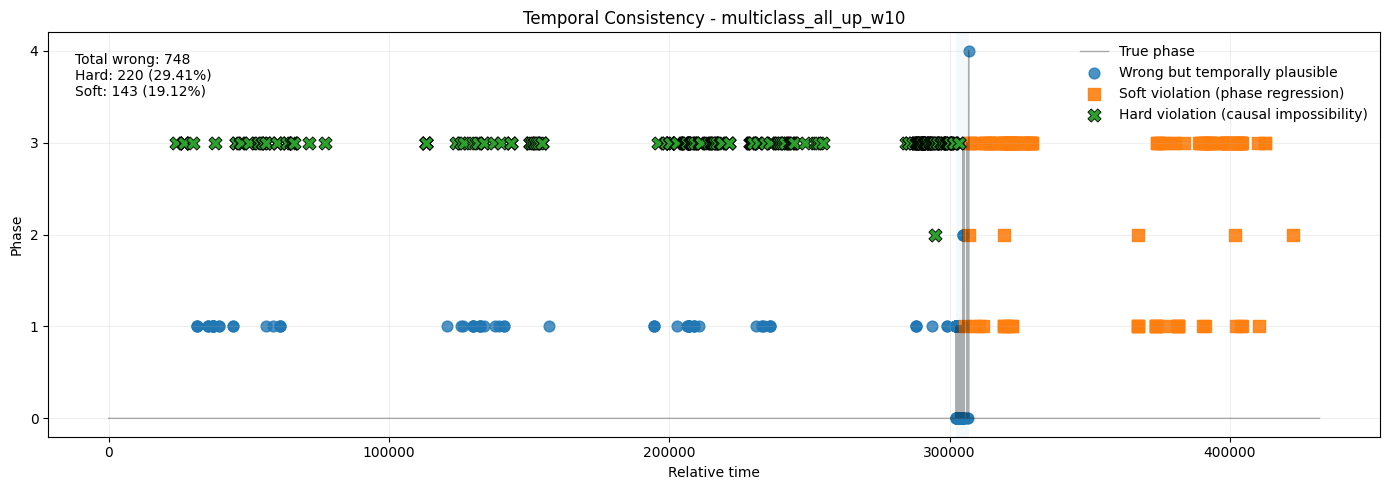

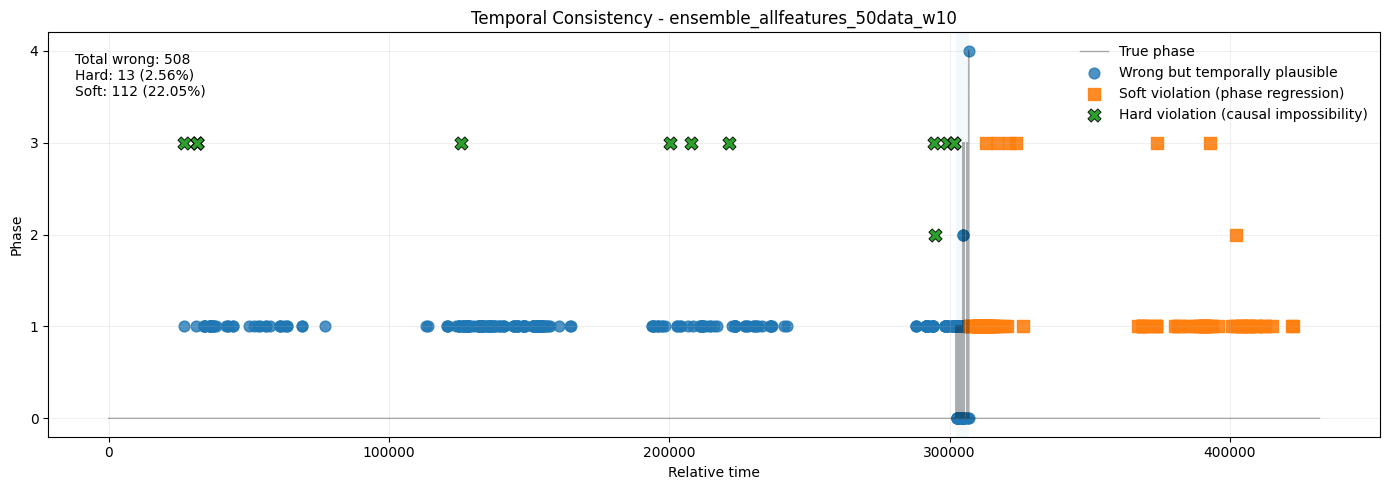

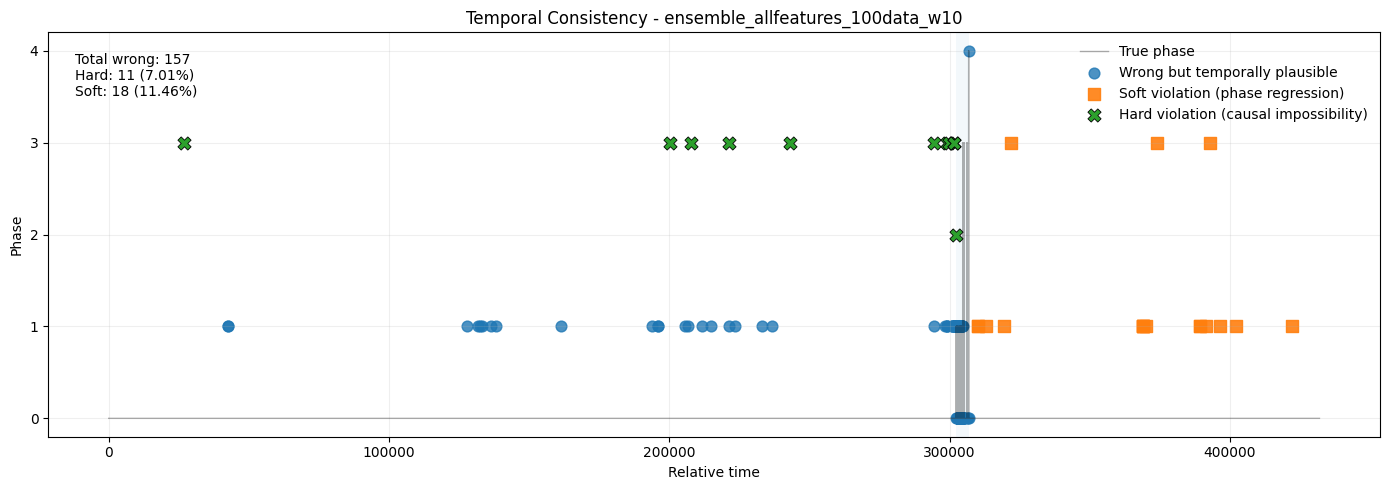

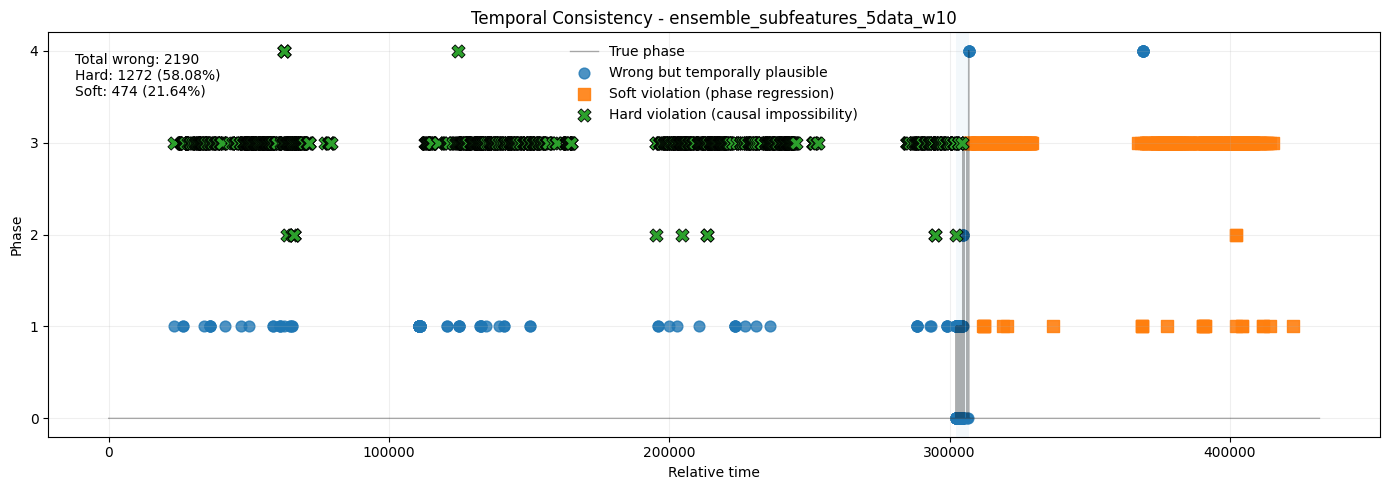

In [31]:
results = []

for file_path in file_paths:

    with open(file_path) as f:
        metrics = json.load(f)

    experiment_name = file_path.stem[:-8]  # Remove "_metrics" suffix

    if "multiclass" in experiment_name:
        model = "multiclass"
    elif "ensemble" in experiment_name:
        model = "ensemble"

    # --- Load misclassification info ---
    real_flow_indices = metrics["real_flow_indices"]
    mis_y_pred = metrics["y_pred"]
    mis_y_true = metrics["y_true"]

    mis_df = df.iloc[real_flow_indices].copy()
    mis_df["y_true"] = mis_y_true
    mis_df["y_pred"] = mis_y_pred

    # --- Compute violation categories ---
    wrong, hard, soft, plausible = mis_metrics(mis_df, phase_start)

    total_wrong = len(wrong)
    hard_rate = len(hard) / total_wrong if total_wrong > 0 else 0
    soft_rate = len(soft) / total_wrong if total_wrong > 0 else 0

    # --- Collect everything ---
    results.append({
        "model": f"{experiment_name}",
        "accuracy": metrics["Accuracy"],
        "precision" : metrics["Macro Precision"],
        "recall" : metrics["Macro Recall"], 
        "f1": metrics["Macro F1"],
        "total_wrong": total_wrong,
        "hard_violations": len(hard),
        "soft_violations": len(soft),
        "hard_rate": hard_rate,
        "soft_rate": soft_rate,
    })

    # Create plots
    plot_mis_predictions(df, phase_bounds, plausible, soft, hard, total_wrong, soft_rate, hard_rate, experiment_name, out_dir)

## Metrics for All Models

In [32]:
results_df = pd.DataFrame(results)

results_df

,model,accuracy,precision,recall,f1,total_wrong,hard_violations,soft_violations,hard_rate,soft_rate
0,multiclass_100data_allfeatures_w10,0.998724,0.855235,0.882548,0.867571,183,13,29,0.071038,0.158470
1,multiclass_subfeatures_50data_w10,0.998040,0.686508,0.856877,0.748070,281,31,25,0.110320,0.088968
2,multiclass_all_up_w10,0.994783,0.617478,0.930118,0.690072,748,220,143,0.294118,0.191176
3,ensemble_allfeatures_50data_w10,0.996457,0.713467,0.898863,0.782584,508,13,112,0.025591,0.220472
4,ensemble_allfeatures_100data_w10,0.998905,0.778516,0.899346,0.821861,157,11,18,0.070064,0.114650
5,ensemble_subfeatures_5data_w10,0.984727,0.484402,0.927537,0.528164,2190,1272,474,0.580822,0.216438


In [33]:
results_df["temporal_score"] = (
    results_df["f1"]
    - 0.5 * results_df["hard_rate"]
    - 0.2 * results_df["soft_rate"]
)

In [34]:
results_df_sorted_f1 = results_df.sort_values("f1", ascending=False)

# Save metrics to file
results_df_sorted_f1.to_csv(
    f"{out_dir}/temporal_consistency_summary.csv",
    index=False
)

In [35]:
results_df_sorted_f1.head()

,model,accuracy,precision,recall,f1,total_wrong,hard_violations,soft_violations,hard_rate,soft_rate,temporal_score
0,multiclass_100data_allfeatures_w10,0.998724,0.855235,0.882548,0.867571,183,13,29,0.071038,0.158470,0.800358
4,ensemble_allfeatures_100data_w10,0.998905,0.778516,0.899346,0.821861,157,11,18,0.070064,0.114650,0.763900
3,ensemble_allfeatures_50data_w10,0.996457,0.713467,0.898863,0.782584,508,13,112,0.025591,0.220472,0.725694
1,multiclass_subfeatures_50data_w10,0.998040,0.686508,0.856877,0.748070,281,31,25,0.110320,0.088968,0.675116
2,multiclass_all_up_w10,0.994783,0.617478,0.930118,0.690072,748,220,143,0.294118,0.191176,0.504778


In [36]:
results_df_sorted_temp = results_df.sort_values("temporal_score", ascending=False)

results_df_sorted_temp.head(10)

,model,accuracy,precision,recall,f1,total_wrong,hard_violations,soft_violations,hard_rate,soft_rate,temporal_score
0,multiclass_100data_allfeatures_w10,0.998724,0.855235,0.882548,0.867571,183,13,29,0.071038,0.158470,0.800358
4,ensemble_allfeatures_100data_w10,0.998905,0.778516,0.899346,0.821861,157,11,18,0.070064,0.114650,0.763900
3,ensemble_allfeatures_50data_w10,0.996457,0.713467,0.898863,0.782584,508,13,112,0.025591,0.220472,0.725694
1,multiclass_subfeatures_50data_w10,0.998040,0.686508,0.856877,0.748070,281,31,25,0.110320,0.088968,0.675116
2,multiclass_all_up_w10,0.994783,0.617478,0.930118,0.690072,748,220,143,0.294118,0.191176,0.504778
5,ensemble_subfeatures_5data_w10,0.984727,0.484402,0.927537,0.528164,2190,1272,474,0.580822,0.216438,0.194465


## Analyze Specific Model

In [41]:
# Hyperparameters for best-performing model
model = "multiclass"
features = "sub"
fraction = 50
window_size = 10

In [44]:
processed_dir = f"../data/processed/{dataset}/{scenario}/windowed"
metrics_dir = f"../experiments/{dataset}/{scenario}/baselines/{model}/metrics"

exp_name = f"{model}_{features}features_{fraction}data_w{window_size}"
metrics_file = f"{metrics_dir}/{exp_name}_metrics.json"

In [47]:
with open(metrics_file) as f:
    metrics = json.load(f)

misclassified_indices = metrics["missclassified_indices"] # fix typo in key name
real_flow_indices = metrics["real_flow_indices"]
mis_y_pred = metrics["y_pred"]
mis_y_true = metrics["y_true"]

mis_df = df.iloc[real_flow_indices].copy()
mis_df["y_true"] = mis_y_true
mis_df["y_pred"] = mis_y_pred


In [48]:
wrong, hard, soft, plausible = mis_metrics(mis_df, phase_start)

total_wrong = len(wrong)

hard_rate = len(hard) / total_wrong if total_wrong > 0 else 0
soft_rate = len(soft) / total_wrong if total_wrong > 0 else 0

print(f"Total wrong: {total_wrong}")
print(f"Hard violations: {len(hard)} ({hard_rate:.2%})")
print(f"Soft violations: {len(soft)} ({soft_rate:.2%})")

Total wrong: 281
Hard violations: 31 (11.03%)
Soft violations: 25 (8.90%)


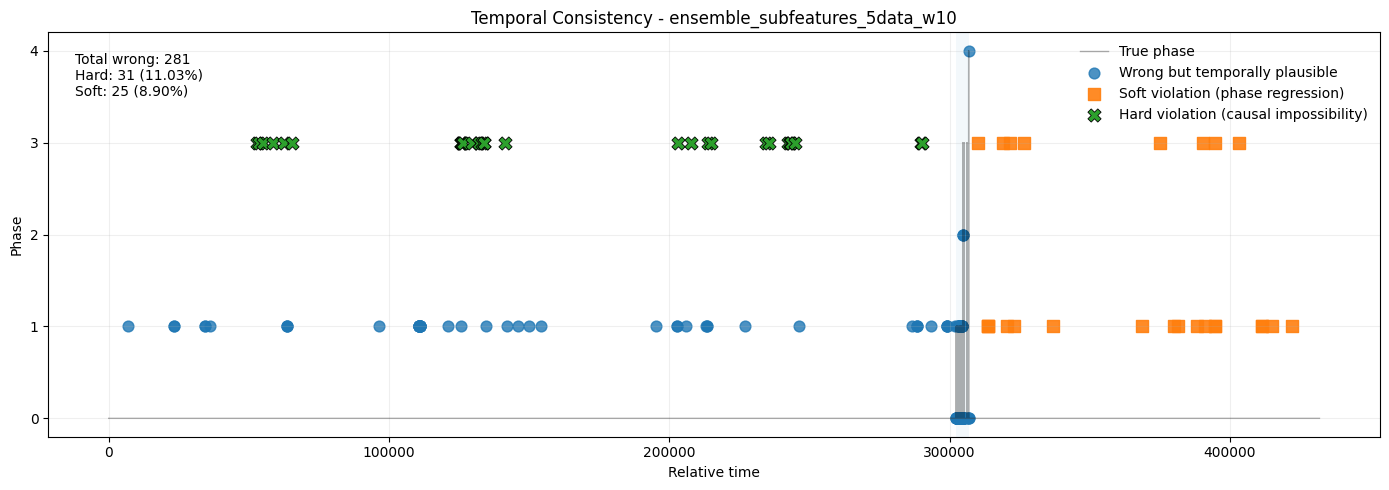

In [49]:
out_dir = ""
plot_mis_predictions(df, phase_bounds, plausible, soft, hard, total_wrong, soft_rate, hard_rate, experiment_name, out_dir, save_plot=False)

In [50]:
mis_only = mis_df[mis_df["y_true"] != mis_df["y_pred"]]

pd.crosstab(
    mis_only["y_true"],
    mis_only["y_pred"],
)

y_pred,0,1,2,3,4
y_true,,,,,
0,0,88,3,39,1
1,133,0,0,0,0
3,17,0,0,0,0
